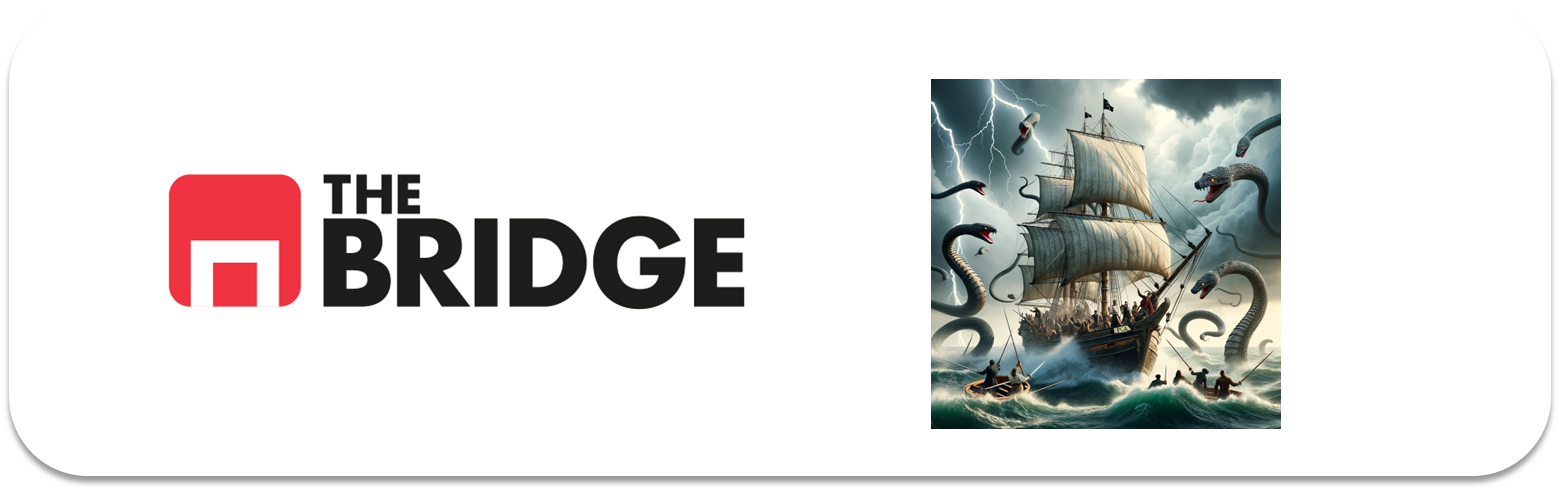

## PRACTICA OBLIGATORIA: **No Supervisado: PCA**

* La práctica obligatoria de esta unidad consiste en aplicar PCA a un dataset de imágenes con diferentes objetivos y compromisos. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### El problema de negocio

El Caesar Palace de las Vegas está planificando la instalación de mil quininetas microcámaras en los accesos a sus instalaciones para las próximas sesiones del "Poker World Championship". Estas microcámaras tienen la peculiaridad de que son capaces de tomar fotos encuadradas de las caras y la desventaja de que no tienen un gran ancho de banda de comunicación. (Las había de más ancho y de mayor precio...). NOTA: El ancho de banda limita el tamaño de las imágenes que pueden enviar las microcámaras).

El objetivo de las microcámaras es el de detectar personas "non-gratas" en tiempo real, pudiendo posprocesar las imágenes para poder detectar si han accedido a las instalaciones personas que estuvieran perseguidas por la ley, en los bancos de datos de los casinos identificadas como "peligrosas" (no se sabe si para el resto de personas o para los beneficios de los casinos) y en las listas de no admisión de jugadores adictos. Por eso no necesitan procesar los datos en tiempo real, pero sí enviarlos a un repositorio central. 

¿Cuál es su problema? O bien comprimen las imágenes y las procesan comprimidas en cada microcámara (pueden comprimir muy rápido pero no tienen cpu para procesarlas sin comprimir) o bien las comprimen y las mandan a un servidor central muy rápido (por eso ti) donde se descomprimirían y se analizarían. Analizar quiere decir en este contexto, pasarles un modelo de clasificación que determine si la persona de la imagen es una de las listas prohibidas (o sea que clasifique la imágen).  

Nos han enviado un dataset y con él debemos estudiar cuál de las dos soluciones es más interesante y dar recomendaciones al respecto. Vamos a ello.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score

### #1 MODELO DE BASE

**Objetivo:** Construir un modelo baseline de clasficación de imágenes que las trate sin comprimir (es decir usando todos sus píxeles).

Para conseguir el objetivo, primero descarga el dataset de las caras de Olivetti que ya has utilizado anteriormente, empleando las funciones de sklearn necesarias. Luego, construye un clasificador con el modelo que consideres más apropiado y todas las features del dataset. Eso sí, recuerda hacer lo siguiente:

1. Construir un data frame con los datos 
2. Hacer un split en train y test con al menos 80 instancias en el test y estratificado según el target. Este split se ha de mantener en el resto de la práctica
3. Hacer un quick miniEDA o justificar el no hacerlo.
4. Medir la recall media (“balanced_accuracy”) sobre cross validation con 5 folds y sobre el conjunto de test y guarda ambas para usarlas como baseline en las siguientes partes




In [2]:
faces = fetch_olivetti_faces()

X = faces.data        # (400, 4096) - cada fila es una imagen aplanada
y = faces.target       # (400,) - 40 personas, etiquetadas 0-39

df = pd.DataFrame(X)
df['target'] = y

print(df.shape)
df.head()

(400, 4097)


,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,target
0,0.309917,0.367769,0.417355,0.442149,0.528926,0.607438,0.657025,0.677686,0.690083,0.685950,...,0.669421,0.652893,0.661157,0.475207,0.132231,0.148760,0.152893,0.161157,0.157025,0
1,0.454545,0.471074,0.512397,0.557851,0.595041,0.640496,0.681818,0.702479,0.710744,0.702479,...,0.157025,0.136364,0.148760,0.152893,0.152893,0.152893,0.152893,0.152893,0.152893,0
2,0.318182,0.400826,0.491736,0.528926,0.586777,0.657025,0.681818,0.685950,0.702479,0.698347,...,0.132231,0.181818,0.136364,0.128099,0.148760,0.144628,0.140496,0.148760,0.152893,0
3,0.198347,0.194215,0.194215,0.194215,0.190083,0.190083,0.243802,0.404959,0.483471,0.516529,...,0.636364,0.657025,0.685950,0.727273,0.743802,0.764463,0.752066,0.752066,0.739669,0
4,0.500000,0.545455,0.582645,0.623967,0.648760,0.690083,0.694215,0.714876,0.723140,0.731405,...,0.161157,0.177686,0.173554,0.177686,0.177686,0.177686,0.177686,0.173554,0.173554,0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(320, 4096) (80, 4096)


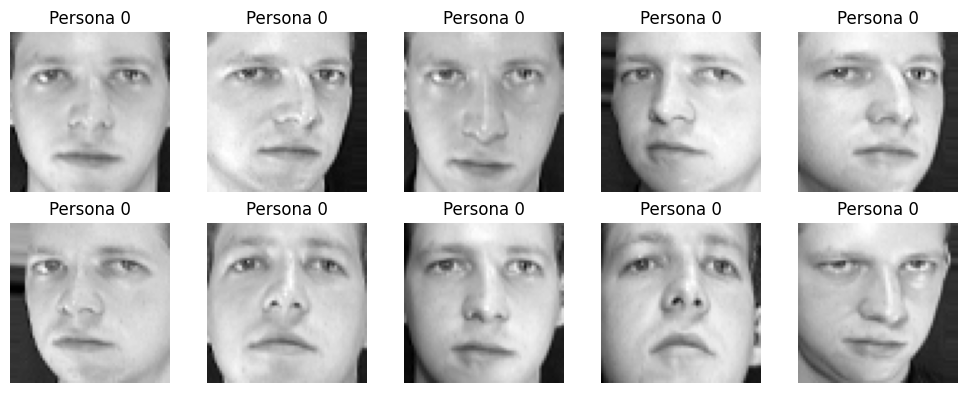

In [6]:
# Creamos una figura con una grilla de 2 filas x 5 columnas para ver 10 caras
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    # Cada fila de X es un vector de 4096 valores (64x64 aplanado)
    # con reshape(64, 64) lo devolvemos a forma de imagen para poder visualizarlo
    ax.imshow(X[i].reshape(64, 64), cmap='gray')
    ax.set_title(f'Persona {y[i]}')  # mostramos a qué persona pertenece la foto
    ax.axis('off')  # quitamos ejes, no aportan nada en una imagen

plt.tight_layout()
plt.show()

In [7]:
# Instanciamos el modelo SVM con kernel lineal
# kernel='linear' porque con muchas features y pocas muestras por clase
# suele funcionar mejor que kernels más complejos (evita overfitting)
modelo_base = SVC(kernel='linear', random_state=42)

# Validación cruzada con 5 folds sobre TRAIN, usando balanced_accuracy como métrica
# (balanced_accuracy = recall medio, que es lo que pide el enunciado)
cv_scores_base = cross_val_score(
    modelo_base, X_train, y_train,
    cv=5, scoring='balanced_accuracy'
)
cv_score_base = cv_scores_base.mean()  # promedio de los 5 folds

# Entrenamos el modelo en todo el train para evaluarlo contra test
modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)
test_score_base = balanced_accuracy_score(y_test, y_pred_base)

print(f"Balanced accuracy en CV (5 folds): {cv_score_base:.4f}")
print(f"Balanced accuracy en test: {test_score_base:.4f}")

Balanced accuracy en CV (5 folds): 0.9625
Balanced accuracy en test: 0.9750


### #2 MODELO PARA LAS MICROCÁMARAS
**Objetivo:** Construir un modelo que pueda funcionar en las microcámaras, es decir que pueda funcionar con datos comprimidos.

Para cumplir con el objetivo se os ocurre emplear la doble propiedad de la PCA, que permite comprimir datos y mantener la capacidad informativa de estos. Sigue los siguientes pasos:
1. Instancia un objeto PCA sobre los datos de Train sin especificar ni componentes ni varianza explicada (o sea sin pasar argumentos).
2. Escoge un rango de valores para el número de PCAs que permitan por lo menos una compresión de la imagen de entre el 0.2% y el 2.5% (prueba al menos 5 valores). NOTA: La compresión es la reducción total, es decir una reducción del 1% quiere decir que el dataset se reduce a un 1% de su tamaño original)
3. Para el rango anterior entrena un modelo de clasificación y apunta su scoring en una validación cruzada de 5 folds y métrica el recall medio y su scoring contra test.
4. Muestra en un dataframe el valor de numero de componentes principales empleado, el scoring en CV, el scoring contra test, el % de compresión, la diferencia con el scoring de CV del modelo base, la diferencia con el scoring en test.
5. Escoge el número de componentes que permitirían tener la mayor compresión con una pérdida inferior a 3 puntos porcentuales tanto en CV como en test. Si no hay escoge el que tenga una pérdida inferior a 5 puntos porcentuales. 

In [8]:
# Instanciamos PCA sin especificar n_components ni varianza explicada
# Esto calcula TODOS los componentes posibles (tantos como min(n_muestras, n_features))
# Lo hacemos así para poder explorar cuánta varianza explica cada uno antes de decidir cuántos usar
pca_explorador = PCA(random_state=42)
pca_explorador.fit(X_train)

print(f"Número de componentes calculados: {pca_explorador.n_components_}")

Número de componentes calculados: 320


In [9]:
# Calculamos qué número de componentes (k) corresponde a cada % de compresión límite
n_features = X_train.shape[1]  # 4096

k_min = 0.002 * n_features  # límite inferior: 0.2% de compresión
k_max = 0.025 * n_features  # límite superior: 2.5% de compresión

print(f"k mínimo (0.2% compresión): {k_min:.1f}")
print(f"k máximo (2.5% compresión): {k_max:.1f}")

k mínimo (0.2% compresión): 8.2
k máximo (2.5% compresión): 102.4


In [10]:
# Elegimos 5 valores de k distribuidos dentro del rango permitido [8, 102]
# Intentamos cubrir bien el rango: extremos y puntos intermedios
valores_k = [10, 25, 50, 75, 100]

# Verificamos a qué % de compresión corresponde cada uno
for k in valores_k:
    compresion = k / n_features * 100
    print(f"k={k} -> compresión: {compresion:.2f}%")

k=10 -> compresión: 0.24%
k=25 -> compresión: 0.61%
k=50 -> compresión: 1.22%
k=75 -> compresión: 1.83%
k=100 -> compresión: 2.44%


In [11]:
# Lista para guardar los resultados de cada k
resultados_microcamara = []

for k in valores_k:
    # Instanciamos PCA con k componentes y la ajustamos SOLO sobre train
    # (si ajustáramos sobre todo el dataset, test "vería" información de train -> data leakage)
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    
    # Transformamos train y test al espacio comprimido de k dimensiones
    X_train_pca = pca.transform(X_train)
    X_test_pca = pca.transform(X_test)
    
    # Entrenamos un SVM lineal igual que en el baseline, pero con los datos comprimidos
    modelo = SVC(kernel='linear', random_state=42)
    
    # Cross validation sobre los datos comprimidos de train
    cv_scores = cross_val_score(
        modelo, X_train_pca, y_train,
        cv=5, scoring='balanced_accuracy'
    )
    cv_score = cv_scores.mean()
    
    # Entrenamos en todo el train comprimido y evaluamos contra test comprimido
    modelo.fit(X_train_pca, y_train)
    y_pred = modelo.predict(X_test_pca)
    test_score = balanced_accuracy_score(y_test, y_pred)
    
    # Guardamos todos los datos de esta iteración
    resultados_microcamara.append({
        'k': k,
        'compresion_%': k / n_features * 100,
        'cv_score': cv_score,
        'test_score': test_score
    })

# Convertimos la lista de resultados a DataFrame para verlo claro
df_microcamara = pd.DataFrame(resultados_microcamara)
print(df_microcamara)

     k  compresion_%  cv_score  test_score
0   10      0.244141    0.8775       0.900
1   25      0.610352    0.9500       0.950
2   50      1.220703    0.9575       0.975
3   75      1.831055    0.9600       0.975
4  100      2.441406    0.9600       0.975


In [12]:
# Añadimos las columnas de diferencia respecto al baseline
# Diferencia = score_baseline - score_actual (positivo = hemos perdido rendimiento)
df_microcamara['diff_cv'] = cv_score_base - df_microcamara['cv_score']
df_microcamara['diff_test'] = test_score_base - df_microcamara['test_score']

print(df_microcamara)

     k  compresion_%  cv_score  test_score  diff_cv  diff_test
0   10      0.244141    0.8775       0.900   0.0850      0.075
1   25      0.610352    0.9500       0.950   0.0125      0.025
2   50      1.220703    0.9575       0.975   0.0050      0.000
3   75      1.831055    0.9600       0.975   0.0025      0.000
4  100      2.441406    0.9600       0.975   0.0025      0.000


In [13]:
# Filtramos las filas donde la pérdida en CV Y en test sea menor a 3 puntos (0.03)
candidatos = df_microcamara[
    (df_microcamara['diff_cv'] < 0.03) & 
    (df_microcamara['diff_test'] < 0.03)
]

print("Candidatos que cumplen <3 puntos de pérdida en CV y test:")
print(candidatos)

# De los candidatos, escogemos el que tenga MENOR k (= mayor compresión)
if len(candidatos) > 0:
    k_elegido_microcamara = candidatos.loc[candidatos['k'].idxmin(), 'k']
    print(f"\nNúmero de componentes elegido: {k_elegido_microcamara}")
else:
    print("Ningún k cumple <3 puntos. Probamos con el criterio de <5 puntos...")

Candidatos que cumplen <3 puntos de pérdida en CV y test:
     k  compresion_%  cv_score  test_score  diff_cv  diff_test
1   25      0.610352    0.9500       0.950   0.0125      0.025
2   50      1.220703    0.9575       0.975   0.0050      0.000
3   75      1.831055    0.9600       0.975   0.0025      0.000
4  100      2.441406    0.9600       0.975   0.0025      0.000

Número de componentes elegido: 25


| Modelo | Compresión | CV score | Test score |
|---|---|---|---|
| Baseline (sin comprimir) | 0% | 0.9625 | 0.9750 |
| PCA k=25 (elegido) | 0.61% | 0.9500 | 0.9500 |

### #3 COMPRESION PARA CLASIFICACION POSTERIOR

**Objetivo**: Obtener el número de componentes que permita una compresión menor y al tiempo que el modelo en el servidor central no baje su rendimiento respecto a no usar imágenes comprimidas.

Para esta parte la idea que se os ha ocurrido es emplear también la PCA como compresor ya que así siempre podrían pasar a la opción anterior si eso fuese suficiente. Pero en este caso no vamos a utilizar el dataset comprimido con las PCAs para detectar las caras, sino el dataset una vez descomprimido (recuerda que puede emplear `inverse_transform` para "descomprimir"). Los pasos a seguir son:

1. Escoge un rango de valores que  permitan una compresión aún mayor (recuerda que el ancho de banda es mínimo) entre el 1 por mil y el 1 por ciento. Escoge 5 valores de número de PCAs que permitan movernos en ese rango.
2. Para cada uno de esos valores: aplica la PCA al X_train, obten un X_train_unzipped aplicando la inversa de la PCA y entrena un modelo de clasificación y pruébalo contra test, apunta el balanced accuracy.
3. Crea un dataframe o haz un visualización comparando como es la medidad de balance accuracy para cada valor de número de pcas escogido y cuál su factor de compresión. 
4. Sabiendo que no podemos perder más de 3 puntos porcentuales respecto al baseline, ¿qué numero de PCA escogerías?

In [14]:
# Calculamos los límites de k para compresión entre 0.1% y 1%
k_min_b3 = 0.001 * n_features  # 1 por mil
k_max_b3 = 0.01 * n_features   # 1 por ciento

print(f"k mínimo (0.1% compresión): {k_min_b3:.1f}")
print(f"k máximo (1% compresión): {k_max_b3:.1f}")

k mínimo (0.1% compresión): 4.1
k máximo (1% compresión): 41.0


In [15]:
# Elegimos 5 valores de k distribuidos dentro del rango permitido [4, 41]
# cubriendo bien desde el extremo de máxima compresión hasta el de mínima
valores_k_b3 = [5, 12, 20, 30, 40]

# Verificamos a qué % de compresión corresponde cada uno
for k in valores_k_b3:
    compresion = k / n_features * 100
    print(f"k={k} -> compresión: {compresion:.3f}%")

k=5 -> compresión: 0.122%
k=12 -> compresión: 0.293%
k=20 -> compresión: 0.488%
k=30 -> compresión: 0.732%
k=40 -> compresión: 0.977%


In [16]:
# Lista para guardar los resultados de cada k en este bloque
resultados_servidor = []

for k in valores_k_b3:
    # Instanciamos PCA con k componentes, ajustada SOLO sobre train
    pca = PCA(n_components=k, random_state=42)
    pca.fit(X_train)
    
    # Comprimimos train y test
    X_train_comprimido = pca.transform(X_train)
    X_test_comprimido = pca.transform(X_test)
    
    # DESCOMPRIMIMOS con inverse_transform -> volvemos a 4096 dimensiones
    # pero la información que contienen es una "aproximación" basada solo en k componentes
    X_train_descomprimido = pca.inverse_transform(X_train_comprimido)
    X_test_descomprimido = pca.inverse_transform(X_test_comprimido)
    
    # Entrenamos el SVM sobre los datos YA DESCOMPRIMIDOS (4096 dimensiones de nuevo)
    modelo = SVC(kernel='linear', random_state=42)
    
    # Cross validation sobre train descomprimido
    cv_scores = cross_val_score(
        modelo, X_train_descomprimido, y_train,
        cv=5, scoring='balanced_accuracy'
    )
    cv_score = cv_scores.mean()
    
    # Entrenamos en todo el train descomprimido y evaluamos contra test descomprimido
    modelo.fit(X_train_descomprimido, y_train)
    y_pred = modelo.predict(X_test_descomprimido)
    test_score = balanced_accuracy_score(y_test, y_pred)
    
    # Guardamos los resultados de esta iteración
    resultados_servidor.append({
        'k': k,
        'compresion_%': k / n_features * 100,
        'cv_score': cv_score,
        'test_score': test_score
    })

# Convertimos a DataFrame
df_servidor = pd.DataFrame(resultados_servidor)
print(df_servidor)

    k  compresion_%  cv_score  test_score
0   5      0.122070    0.7275      0.6875
1  12      0.292969    0.8950      0.9000
2  20      0.488281    0.9500      0.9375
3  30      0.732422    0.9500      0.9625
4  40      0.976562    0.9575      0.9625


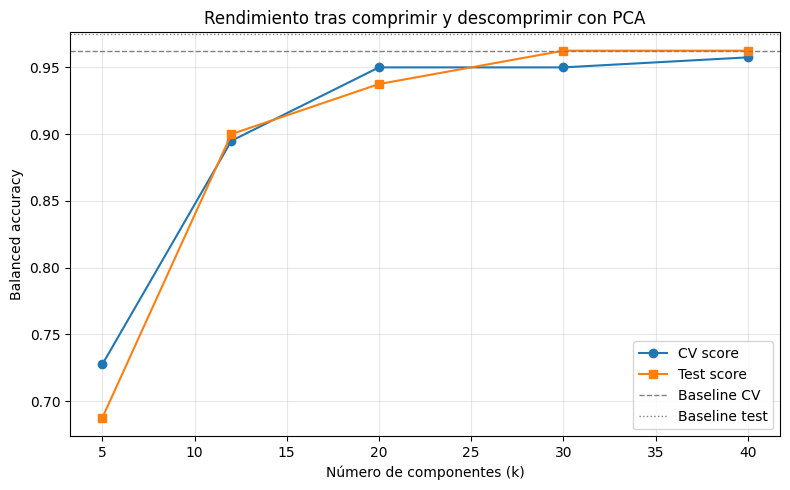

In [17]:
# Gráfica comparando balanced accuracy (CV y test) frente al número de componentes
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_servidor['k'], df_servidor['cv_score'], marker='o', label='CV score')
ax.plot(df_servidor['k'], df_servidor['test_score'], marker='s', label='Test score')

# Líneas horizontales de referencia con el baseline (sin comprimir)
ax.axhline(cv_score_base, color='gray', linestyle='--', linewidth=1, label='Baseline CV')
ax.axhline(test_score_base, color='gray', linestyle=':', linewidth=1, label='Baseline test')

ax.set_xlabel('Número de componentes (k)')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Rendimiento tras comprimir y descomprimir con PCA')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Calculamos la pérdida respecto al baseline para cada k
df_servidor['diff_cv'] = cv_score_base - df_servidor['cv_score']
df_servidor['diff_test'] = test_score_base - df_servidor['test_score']

# Filtramos los que cumplen <3 puntos de pérdida en CV y test
candidatos_b3 = df_servidor[
    (df_servidor['diff_cv'] < 0.03) &
    (df_servidor['diff_test'] < 0.03)
]

print(candidatos_b3)

# Elegimos el de menor k (mayor compresión) entre los candidatos
if len(candidatos_b3) > 0:
    k_elegido_b3 = candidatos_b3.loc[candidatos_b3['k'].idxmin(), 'k']
    print(f"\nNúmero de componentes elegido: {k_elegido_b3}")

    k  compresion_%  cv_score  test_score  diff_cv  diff_test
3  30      0.732422    0.9500      0.9625   0.0125     0.0125
4  40      0.976562    0.9575      0.9625   0.0050     0.0125

Número de componentes elegido: 30


## Resumen final

| Escenario | Compresión | CV score | Test score | Pérdida vs baseline |
|---|---|---|---|---|
| Baseline (sin comprimir) | 0% | 0.9625 | 0.9750 | — |
| Microcámara (k=25) | 0.61% | 0.9500 | 0.9500 | 1.25 / 2.50 pts |
| Servidor central (k=30) | 0.73% | 0.9500 | 0.9625 | 1.25 / 1.25 pts |

Con PCA se puede comprimir las imágenes a menos del 1% de su tamaño original sin perder casi rendimiento (menos de 2.5 puntos en todos los casos). La opción de la microcámara (clasificar directamente el dato comprimido) es la más recomendable: logra una compresión similar a la otra opción pero con menos pasos y menos coste de cómputo en el servidor.

### #EXTRA

1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)
2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.

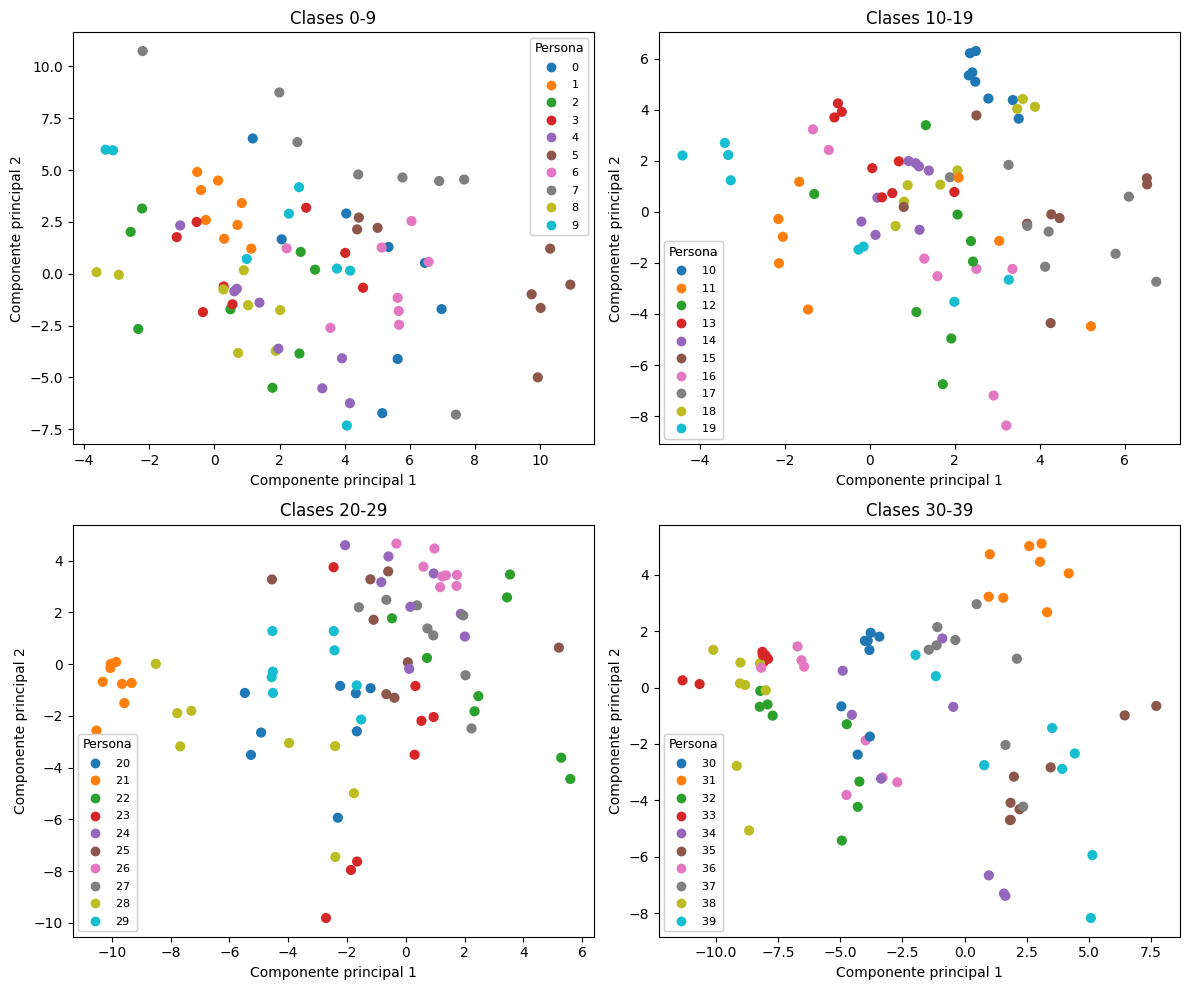

In [21]:
#1. Para la segunda parte, visualiza en cuatro gráficos un scatter plot de las dos primeras componentes principales de la PCA escogida y colorea cada punto con las clases correspondientes a cada cara (como hay 40 clases, usa 10 por gráfico, 1-10 en el primero, 11-20 en el segundo, etc)

# Reutilizamos la PCA ya entrenada en el Bloque #2 con k=25 sobre X_train
pca_b2 = PCA(n_components=25, random_state=42)
pca_b2.fit(X_train)

# Transformamos X_train al espacio de componentes principales
X_train_pca_b2 = pca_b2.transform(X_train)

# Nos quedamos solo con las 2 primeras componentes para el scatter plot
pc1 = X_train_pca_b2[:, 0]
pc2 = X_train_pca_b2[:, 1]

# Creamos una figura con 4 subgráficos (2 filas x 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Definimos los 4 rangos de clases: 0-9, 10-19, 20-29, 30-39
# (las clases van de 0 a 39, así que "1-10" en la práctica equivale a las clases 0-9 en código)
rangos = [(0, 10), (10, 20), (20, 30), (30, 40)]

for ax, (inicio, fin) in zip(axes.flat, rangos):
    # Máscara booleana: True para las filas de y_train cuya clase cae en este rango
    mask = (y_train >= inicio) & (y_train < fin)
    
    # Scatter plot solo de esos puntos, coloreado según la clase (c=y_train[mask])
    scatter = ax.scatter(pc1[mask], pc2[mask], c=y_train[mask], cmap='tab10', s=40)
    
    ax.set_title(f'Clases {inicio}-{fin-1}')
    ax.set_xlabel('Componente principal 1')
    ax.set_ylabel('Componente principal 2')
    
    # Leyenda de colores para este subgráfico
    legend = ax.legend(*scatter.legend_elements(), title="Persona", 
                        loc='best', fontsize=8, title_fontsize=9)
    ax.add_artist(legend)

plt.tight_layout()
plt.show()

In [22]:
#2. Para la tercer parte crea una función (modifica la de la práctica de la unidad de KMeans, por ejemplo) que permita ver la cara sin comprimir y la cara después de haberla descomprimido y haz una comprobación de cómo quedan (visualiza 5 caras por ejemplo) para cada uno de los valores de números de PCAs probados. Añade el caso para 150 y 320 PCs para que se vea que son las mismas claras con claridad.
def comparar_caras_comprimidas(X_original, k, n_caras=5, random_state=42):
    """
    Muestra n_caras comparando la imagen original con su versión
    comprimida y descomprimida usando PCA con k componentes.
    
    Parámetros:
    - X_original: array de imágenes sin comprimir (n_muestras, 4096)
    - k: número de componentes principales a usar
    - n_caras: cuántas caras mostrar (por defecto 5)
    - random_state: semilla para elegir las caras y para la PCA
    """
    # Fijamos la semilla para elegir siempre las mismas caras de ejemplo
    rng = np.random.RandomState(random_state)
    indices = rng.choice(X_original.shape[0], size=n_caras, replace=False)
    
    # Ajustamos la PCA con k componentes sobre los datos originales
    pca = PCA(n_components=k, random_state=random_state)
    pca.fit(X_original)
    
    # Comprimimos y descomprimimos las imágenes seleccionadas
    X_comprimido = pca.transform(X_original[indices])
    X_descomprimido = pca.inverse_transform(X_comprimido)
    
    # Creamos una figura con 2 filas (original / reconstruida) x n_caras columnas
    fig, axes = plt.subplots(2, n_caras, figsize=(2 * n_caras, 4))
    fig.suptitle(f'Comparación con k={k} componentes', fontsize=14)
    
    for col, idx in enumerate(indices):
        # Fila 0: imagen original sin comprimir
        axes[0, col].imshow(X_original[idx].reshape(64, 64), cmap='gray')
        axes[0, col].axis('off')
        if col == 0:
            axes[0, col].set_ylabel('Original')
        
        # Fila 1: imagen reconstruida tras compresión/descompresión
        axes[1, col].imshow(X_descomprimido[col].reshape(64, 64), cmap='gray')
        axes[1, col].axis('off')
        if col == 0:
            axes[1, col].set_ylabel('Reconstruida')
    
    plt.tight_layout()
    plt.show()

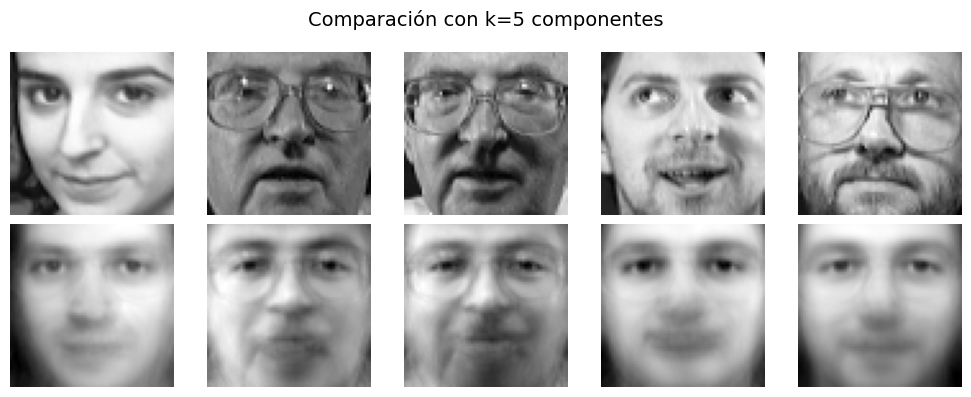

In [23]:
comparar_caras_comprimidas(X_train, k=5)

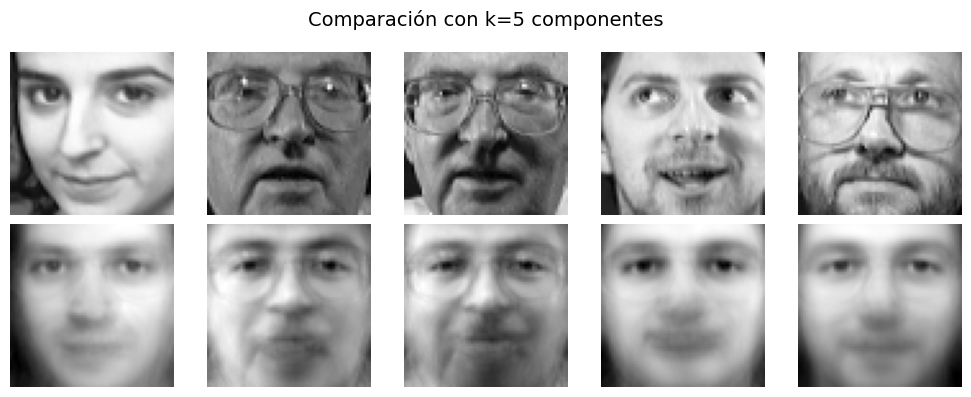

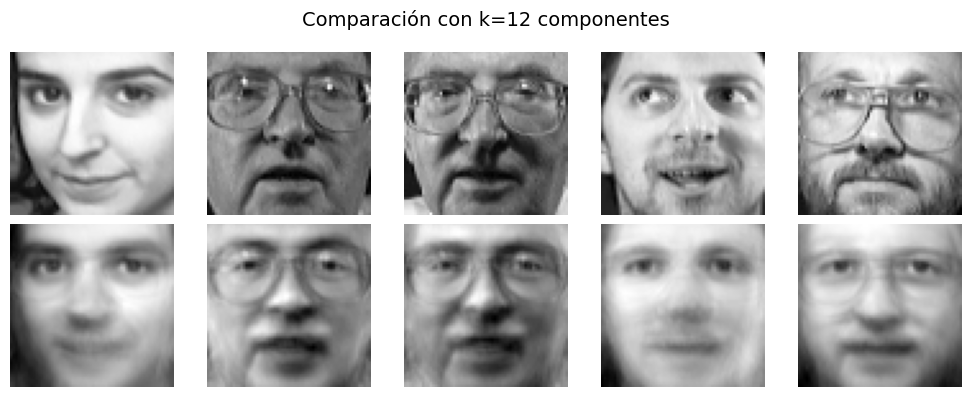

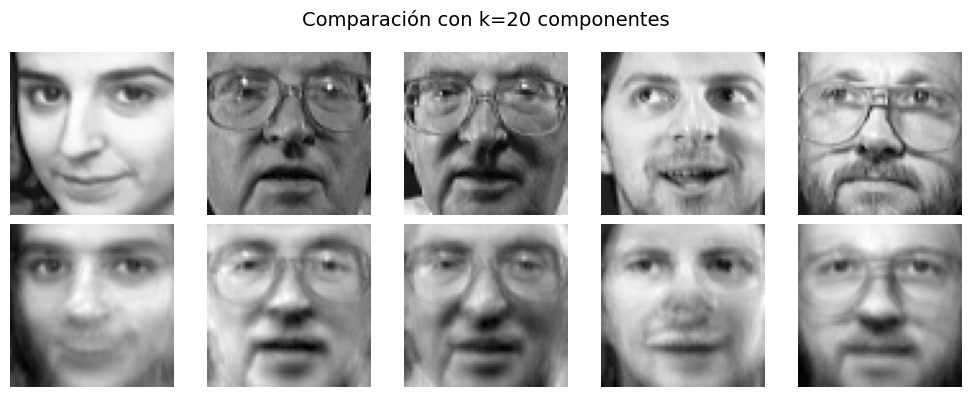

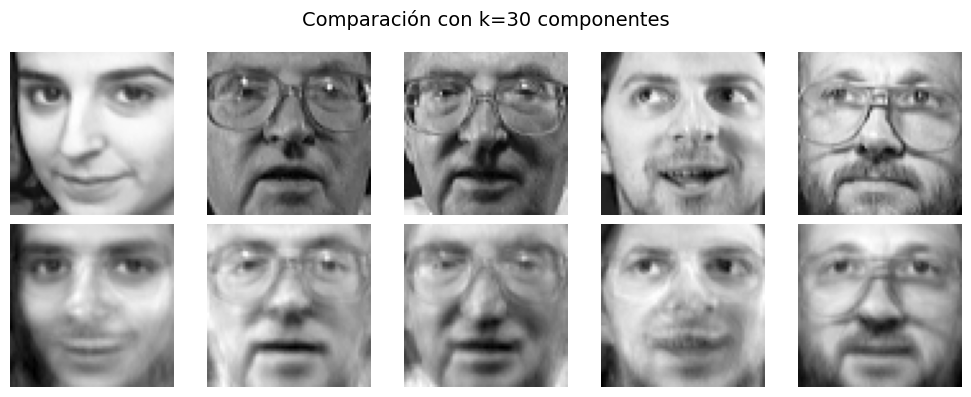

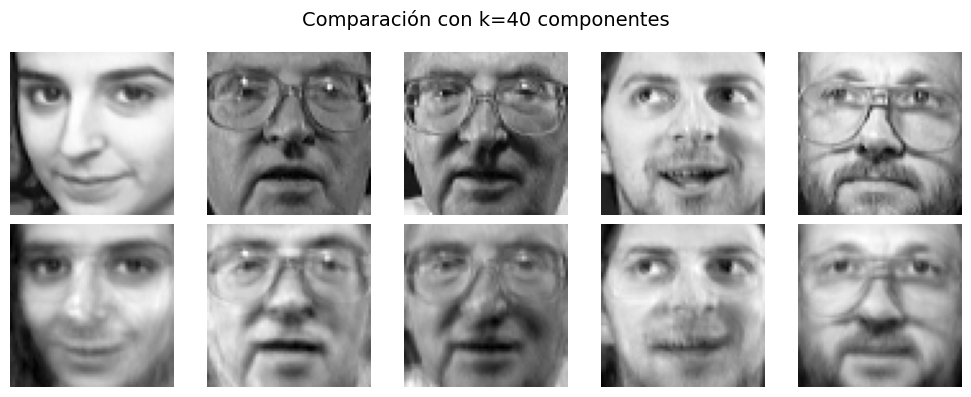

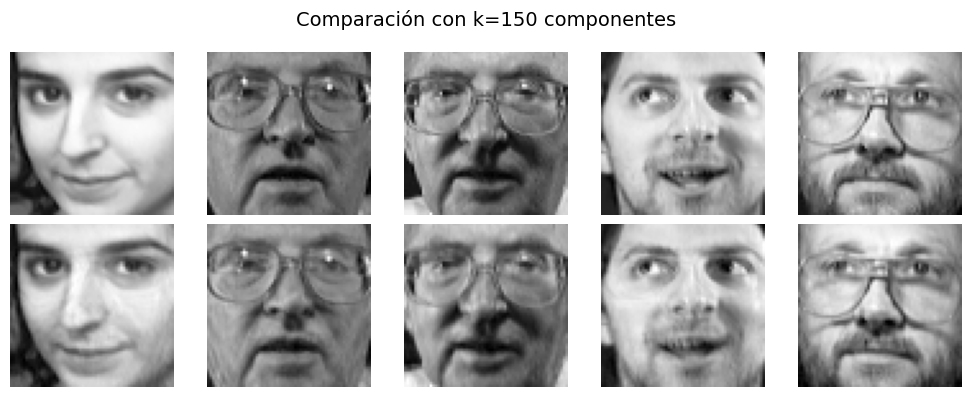

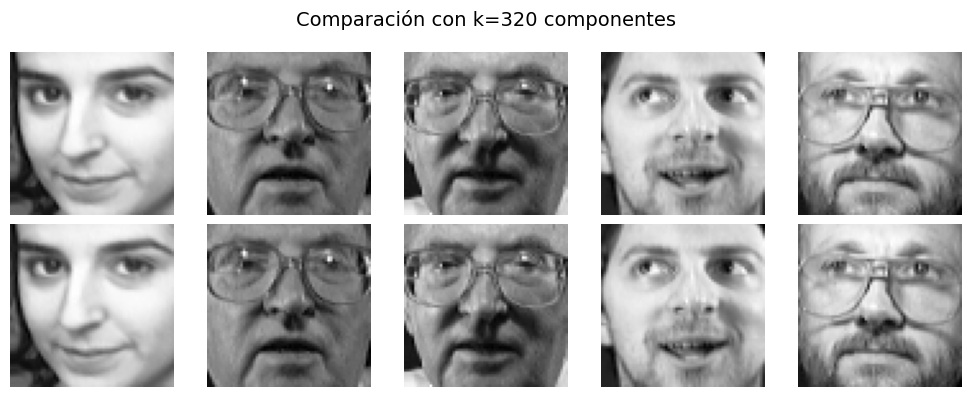

In [24]:
# Valores de k a comparar: los 5 del Bloque #3 + 150 y 320 (el máximo posible)

valores_k_extra = valores_k_b3 + [150, 320]

for k in valores_k_extra:
    comparar_caras_comprimidas(X_train, k=k)

## Resumen de los extras

**Extra 1:** Al visualizar las 2 primeras componentes principales, se ve que algunas personas se separan bien en el plano (ej. persona 9, persona 11), pero la mayoría se solapan. Esto es normal: solo estamos viendo 2 de las 25 dimensiones que realmente usa el clasificador.

**Extra 2:** Con pocos componentes (k=5) las caras reconstruidas salen muy borrosas, perdiendo gafas, expresión y rasgos finos. A medida que aumenta k, la reconstrucción mejora progresivamente, y con k=320 (el máximo) la imagen reconstruida es prácticamente idéntica a la original. Esto confirma visualmente el trade-off entre compresión y calidad que vimos numéricamente en los bloques anteriores.